In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [3]:
##this is list of all models and methods we are going to use to build and measure our model, for both classification and regression part

In [98]:
from sklearn.preprocessing import OneHotEncoder,RobustScaler,OrdinalEncoder,PowerTransformer
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,confusion_matrix,accuracy_score,classification_report,roc_auc_score, roc_curve,auc
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge,Lasso,ElasticNet,RidgeClassifier
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor,AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
from xgboost import XGBRegressor,XGBClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from scipy.stats import skew,boxcox
from lightgbm import LGBMRegressor,LGBMClassifier
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.svm import SVC,SVR
from sklearn.naive_bayes import GaussianNB
from scipy.stats import spearmanr

In [5]:
#CSV file is turned into dataframe so we can build or model
df=pd.read_csv('../sources/Turkish_vehicle_data_set_2026.csv')

This is the explantion of our columns:
'province': Which province the vehicle is registered to?
'brand': Which brand the vehicle belongs to?
'model': Which model the vehicle belongs to?
'fuel_type': Which fuel type does the vehicle use?
'transmission_type': Which transmission type does the vehicle have?
'engine_size_cc': What engine size does the vehicle have?
'num_seats': How many seats does the vehicle have?
'vehicle_type': What type is the vehicle?
'vehicle_age_years': How old is the vehicle?
'vehicle_value_TRY': How much is the vehicle worth?
'prev_owners': How many previous owners does the vehicle have?
'vehicle_usage_purpose': For what purpose is the vehicle primarily used (e.g., Private, Company Fleet, Taxi)?
'usage_type': In what type of environment is the vehicle mainly driven (e.g., Urban, Rural, Mixed)?
'driver_age': How old is the primary driver?
'driving_exp_years': How many years of driving experience does the primary driver have?
'gender': What is the gender of the primary driver?
'annual_mileage_km': How many kilometers is the vehicle driven annually?
'prev_claims_3yr': How many insurance claims were filed in the previous 3 years?
'has_garage': Is the vehicle regularly parked in a garage?
'anti_theft_device': Does the vehicle have an anti-theft device installed?
'policy_tenure_years': How many years has the insurance policy been active with the provider?
'coverage_type': What type of insurance coverage does the vehicle hold (e.g., Comprehensive, Third-Party+)?
'had_claim': Did the vehicle have an insurance claim filed during the observed period?
'claim_cost_TRY': If a claim was filed, what was the total cost of the claim in Turkish Lira (TRY)?'vehicle_usage_purpose':
'usage_type': 
'driver_age': 
'driving_exp_years':
'gender':
'annual_mileage_km':
'prev_claims_3yr':
'has_garage':
'anti_theft_device':
'policy_tenure_years':
'coverage_type':
'had_claim':
'claim_cost_TRY':

In [6]:
#we can see that there are 24 columns , 10 categorical, 14 numeric columns, we will start to change categorical columns to numeric ones
#so that we can use them in our model
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               10000 non-null  object
 1   brand                  10000 non-null  object
 2   model                  10000 non-null  object
 3   fuel_type              10000 non-null  object
 4   transmission_type      10000 non-null  object
 5   engine_size_cc         10000 non-null  int64 
 6   num_seats              10000 non-null  int64 
 7   vehicle_type           10000 non-null  object
 8   vehicle_age_years      10000 non-null  int64 
 9   vehicle_value_TRY      10000 non-null  int64 
 10  prev_owners            10000 non-null  int64 
 11  vehicle_usage_purpose  10000 non-null  object
 12  usage_type             10000 non-null  object
 13  driver_age             10000 non-null  int64 
 14  driving_exp_years      10000 non-null  int64 
 15  gender              

In [7]:
#to be sure %100  isnull sum is called to check na rows..
df.isnull().sum()

province                 0
brand                    0
model                    0
fuel_type                0
transmission_type        0
engine_size_cc           0
num_seats                0
vehicle_type             0
vehicle_age_years        0
vehicle_value_TRY        0
prev_owners              0
vehicle_usage_purpose    0
usage_type               0
driver_age               0
driving_exp_years        0
gender                   0
annual_mileage_km        0
prev_claims_3yr          0
has_garage               0
anti_theft_device        0
policy_tenure_years      0
coverage_type            0
had_claim                0
claim_cost_TRY           0
dtype: int64

In [8]:
#also numeric columns are checked whethere there are something irregular  
df.describe()

,engine_size_cc,num_seats,vehicle_age_years,vehicle_value_TRY,prev_owners,driver_age,driving_exp_years,gender,annual_mileage_km,prev_claims_3yr,has_garage,anti_theft_device,policy_tenure_years,had_claim,claim_cost_TRY
count,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1444.997800,5.307600,14.302400,3.310656e+05,1.129500,46.583700,26.390700,0.447500,42577.497400,0.610100,0.597800,0.642600,7.974500,0.356800,23880.920000
std,386.663752,0.960247,8.964451,2.468272e+05,1.105284,16.737139,16.255229,0.497261,21786.165591,0.888345,0.490366,0.479258,4.321541,0.479079,48491.211366
min,0.000000,2.000000,1.000000,3.600000e+04,0.000000,18.000000,0.000000,0.000000,5000.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1305.000000,5.000000,6.000000,1.330000e+05,0.000000,32.000000,12.000000,0.000000,23627.750000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000
50%,1495.000000,5.000000,14.000000,2.640000e+05,1.000000,47.000000,27.000000,0.000000,42307.000000,0.000000,1.000000,1.000000,8.000000,0.000000,0.000000
75%,1662.000000,5.000000,22.000000,4.770000e+05,2.000000,61.000000,41.000000,1.000000,61680.000000,1.000000,1.000000,1.000000,12.000000,1.000000,32125.000000
max,2962.000000,12.000000,30.000000,1.845000e+06,4.000000,75.000000,50.000000,1.000000,79991.000000,4.000000,1.000000,1.000000,15.000000,1.000000,715300.000000


In [9]:
df.columns

Index(['province', 'brand', 'model', 'fuel_type', 'transmission_type',
       'engine_size_cc', 'num_seats', 'vehicle_type', 'vehicle_age_years',
       'vehicle_value_TRY', 'prev_owners', 'vehicle_usage_purpose',
       'usage_type', 'driver_age', 'driving_exp_years', 'gender',
       'annual_mileage_km', 'prev_claims_3yr', 'has_garage',
       'anti_theft_device', 'policy_tenure_years', 'coverage_type',
       'had_claim', 'claim_cost_TRY'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               10000 non-null  object
 1   brand                  10000 non-null  object
 2   model                  10000 non-null  object
 3   fuel_type              10000 non-null  object
 4   transmission_type      10000 non-null  object
 5   engine_size_cc         10000 non-null  int64 
 6   num_seats              10000 non-null  int64 
 7   vehicle_type           10000 non-null  object
 8   vehicle_age_years      10000 non-null  int64 
 9   vehicle_value_TRY      10000 non-null  int64 
 10  prev_owners            10000 non-null  int64 
 11  vehicle_usage_purpose  10000 non-null  object
 12  usage_type             10000 non-null  object
 13  driver_age             10000 non-null  int64 
 14  driving_exp_years      10000 non-null  int64 
 15  gender              

In [11]:
#in order to decide which encoding we will use for different columns, we need to see different values of categorical columns:
#we can see that we can use map method for transmission_type,coverage_type columns because there are two values for each of them. 
categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}")
    print(df[col].unique())

province
['Kütahya' 'Mersin' 'Ordu' 'Kayseri' 'Ankara' 'Şirnak' 'Konya' 'Manisa'
 'İstanbul' 'Gaziantep' 'Trabzon' 'İzmir' 'Muğla' 'Balikesir' 'Eskişehir'
 'Kirikkale' 'Samsun' 'Malatya' 'Aydin' 'Ağri' 'Antalya' 'Karaman'
 'Diyarbakir' 'Artvin' 'Denizli' 'Hatay' 'Çanakkale' 'Adana' 'Çorum'
 'Adiyaman' 'Isparta' 'Niğde' 'Bingöl' 'Bursa' 'Kahramanmaraş' 'Kocaeli'
 'Giresun' 'Aksaray' 'Tekirdağ' 'Kirşehir' 'Sivas' 'Afyonkarahisar'
 'Edirne' 'Zonguldak' 'Şanliurfa' 'Sinop' 'Tokat' 'Yozgat' 'Amasya'
 'Osmaniye' 'Burdur' 'Sakarya' 'Kastamonu' 'Kirklareli' 'Bilecik' 'Bolu'
 'Nevşehir' 'Iğdir' 'Hakkari' 'Çankiri' 'Van' 'Uşak' 'Elaziğ' 'Kilis'
 'Düzce' 'Erzincan' 'Yalova' 'Karabük' 'Bartin' 'Bitlis' 'Erzurum'
 'Gümüşhane' 'Rize' 'Muş' 'Mardin' 'Siirt' 'Ardahan' 'Batman' 'Kars'
 'Tunceli' 'Bayburt']
brand
['Kia' 'BMW' 'Toyota' 'Volkswagen' 'Opel' 'Fiat' 'Skoda' 'Renault' 'Ford'
 'Togg' 'Citroen' 'Hyundai' 'Other' 'Dacia' 'Peugeot' 'Mercedes' 'Honda']
model
['Niro' 'X1' 'Corolla' 'T-Roc' 'Astra' 

In [12]:
#we will change Third-Party+ as 0 and Comprehensive as 1 for coverage_type and transmission_type we will use Automatic as 0 and manuel 1 
df['coverage_type']=df['coverage_type'].map({'Third-Party+':0,'Comprehensive':1})
df['transmission_type']=df['transmission_type'].map({'Automatic':0,'Manual':1})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               10000 non-null  object
 1   brand                  10000 non-null  object
 2   model                  10000 non-null  object
 3   fuel_type              10000 non-null  object
 4   transmission_type      10000 non-null  int64 
 5   engine_size_cc         10000 non-null  int64 
 6   num_seats              10000 non-null  int64 
 7   vehicle_type           10000 non-null  object
 8   vehicle_age_years      10000 non-null  int64 
 9   vehicle_value_TRY      10000 non-null  int64 
 10  prev_owners            10000 non-null  int64 
 11  vehicle_usage_purpose  10000 non-null  object
 12  usage_type             10000 non-null  object
 13  driver_age             10000 non-null  int64 
 14  driving_exp_years      10000 non-null  int64 
 15  gender              

In [14]:
 categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}")
    print(df[col].unique())

province
['Kütahya' 'Mersin' 'Ordu' 'Kayseri' 'Ankara' 'Şirnak' 'Konya' 'Manisa'
 'İstanbul' 'Gaziantep' 'Trabzon' 'İzmir' 'Muğla' 'Balikesir' 'Eskişehir'
 'Kirikkale' 'Samsun' 'Malatya' 'Aydin' 'Ağri' 'Antalya' 'Karaman'
 'Diyarbakir' 'Artvin' 'Denizli' 'Hatay' 'Çanakkale' 'Adana' 'Çorum'
 'Adiyaman' 'Isparta' 'Niğde' 'Bingöl' 'Bursa' 'Kahramanmaraş' 'Kocaeli'
 'Giresun' 'Aksaray' 'Tekirdağ' 'Kirşehir' 'Sivas' 'Afyonkarahisar'
 'Edirne' 'Zonguldak' 'Şanliurfa' 'Sinop' 'Tokat' 'Yozgat' 'Amasya'
 'Osmaniye' 'Burdur' 'Sakarya' 'Kastamonu' 'Kirklareli' 'Bilecik' 'Bolu'
 'Nevşehir' 'Iğdir' 'Hakkari' 'Çankiri' 'Van' 'Uşak' 'Elaziğ' 'Kilis'
 'Düzce' 'Erzincan' 'Yalova' 'Karabük' 'Bartin' 'Bitlis' 'Erzurum'
 'Gümüşhane' 'Rize' 'Muş' 'Mardin' 'Siirt' 'Ardahan' 'Batman' 'Kars'
 'Tunceli' 'Bayburt']
brand
['Kia' 'BMW' 'Toyota' 'Volkswagen' 'Opel' 'Fiat' 'Skoda' 'Renault' 'Ford'
 'Togg' 'Citroen' 'Hyundai' 'Other' 'Dacia' 'Peugeot' 'Mercedes' 'Honda']
model
['Niro' 'X1' 'Corolla' 'T-Roc' 'Astra' 

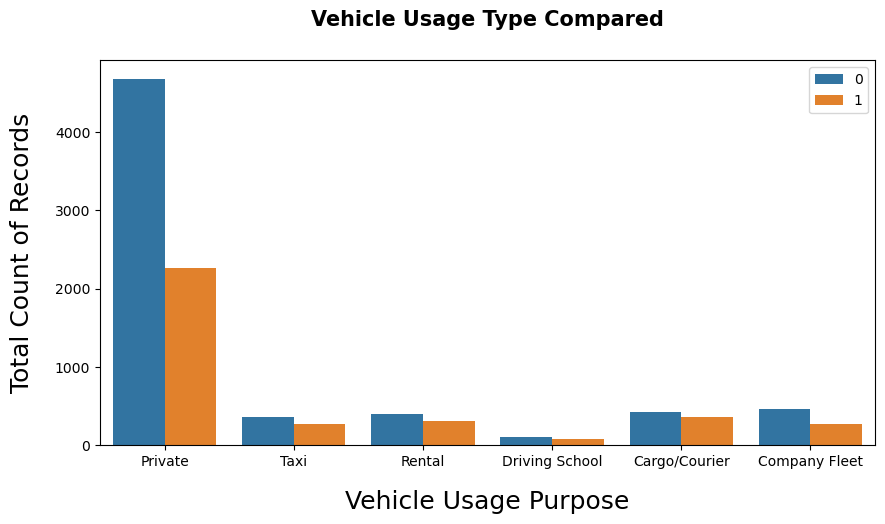

In [15]:
#in order to understand categorical columns with less columns, we will check their claim ratios 
#first I tried vehicle usage purpose column and noticed that if the vehicle is not private there is certain higher chance to have a claim therefore I will 
#use targer encoding 
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='vehicle_usage_purpose', hue='had_claim')
plt.title('Vehicle Usage Type Compared', fontsize=15, pad=25, fontweight='bold')
plt.xlabel('Vehicle Usage Purpose', fontsize=18, labelpad=15)
plt.ylabel('Total Count of Records', fontsize=18, labelpad=15)
plt.legend()
plt.savefig('vehicle_usage_type_compared.png', dpi=500, bbox_inches='tight')
plt.show()

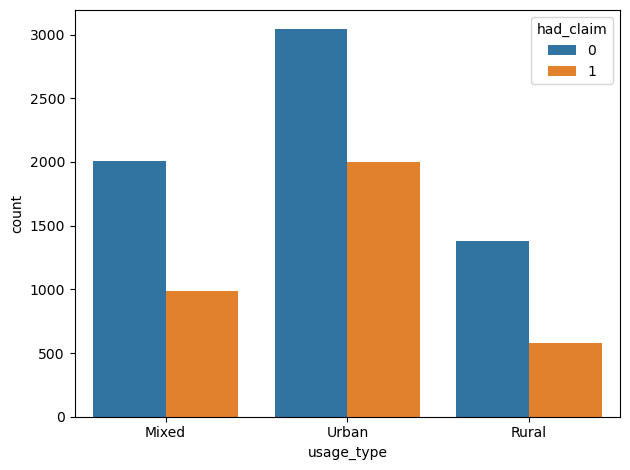

In [16]:
#then I 've checked usage_type  and  noticed that Urban vehicles tend to have more likely to have claim therefore I would use target coding for this
figsize=(20,5)
sns.countplot(data=df,x='usage_type',hue='had_claim')
plt.tight_layout()
plt.show()

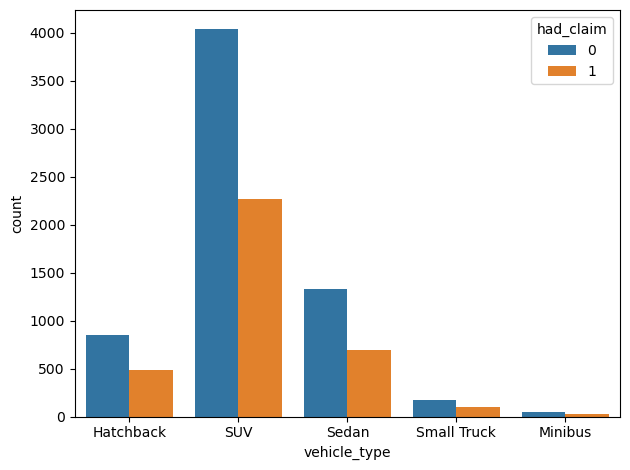

In [17]:
##When vehicle_type is checked, I see that there is no certain relationship between values and had claim here therefore I can use OneHotEncoding
figsize=(20,5)
sns.countplot(data=df,x='vehicle_type',hue='had_claim')
plt.tight_layout()
plt.show()

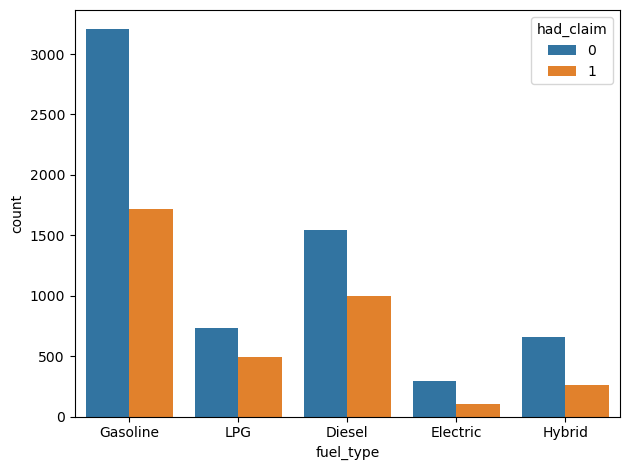

In [18]:
##Same conculision for fuel_type
figsize=(20,5)
sns.countplot(data=df,x='fuel_type',hue='had_claim')
plt.tight_layout()
plt.show()

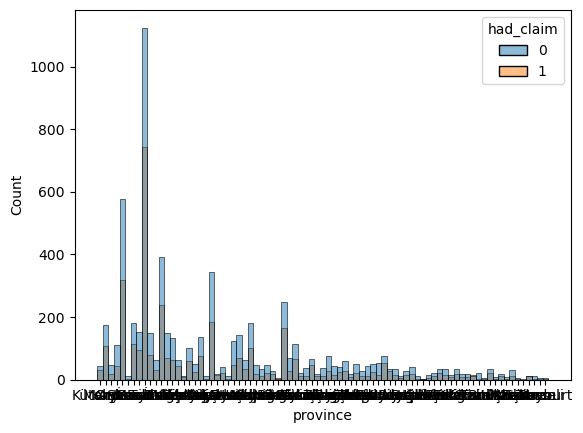

In [19]:
#let's which provinces have most claims.. I will hisplot but since there are lots of provinces, this method does not work, so I will first use groupby
#take first ten provinces..
figsize=(15,15)
sns.histplot(data=df,x='province',hue='had_claim')
plt.show()

In [20]:
province_topclaims=df.groupby('province')['had_claim'].count().sort_values(ascending=False)

In [21]:
first_ten=province_topclaims.head(10)

In [22]:
last_ten=province_topclaims.tail(10)

C:\Users\dolap\AppData\Local\Temp\ipykernel_26768\1428546494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_ten.values,y=first_ten.index,palette='Reds_r')


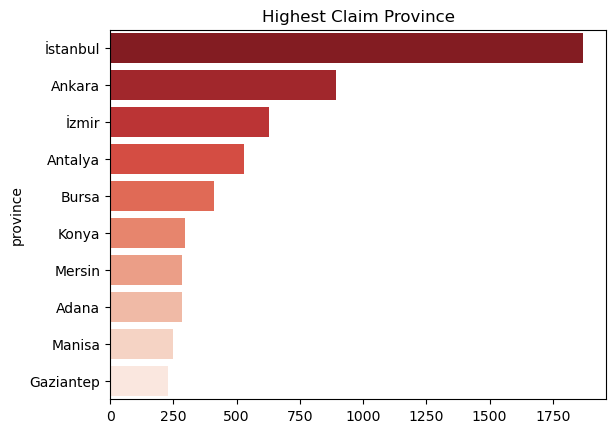

In [23]:
figsize=(15,15)
sns.barplot(x=first_ten.values,y=first_ten.index,palette='Reds_r')
plt.title('Highest Claim Province')
plt.savefig('Highest_Claim_Province.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\dolap\AppData\Local\Temp\ipykernel_26768\2776297757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='had_claim', palette=['#4c72b0', '#c44e52'])


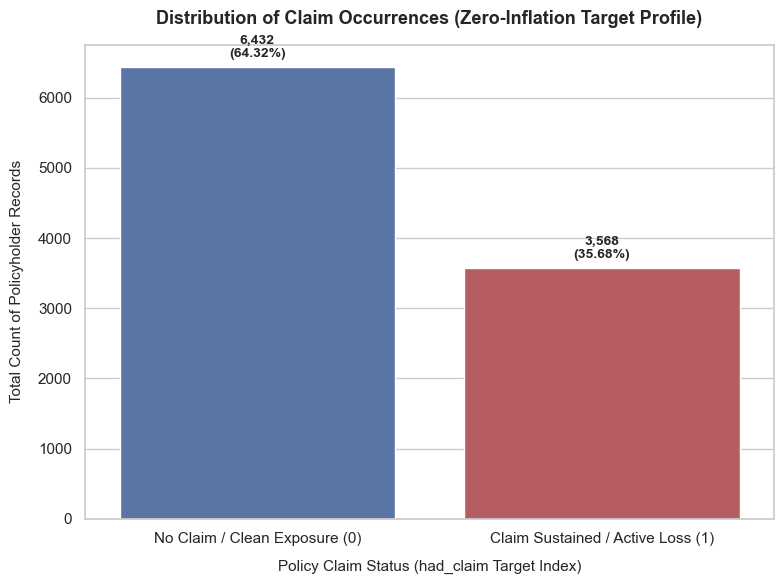

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='had_claim', palette=['#4c72b0', '#c44e52'])
plt.title('Distribution of Claim Occurrences (Zero-Inflation Target Profile)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Policy Claim Status (had_claim Target Index)', fontsize=11, labelpad=10)
plt.ylabel('Total Count of Policyholder Records', fontsize=11, labelpad=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Claim / Clean Exposure (0)', 'Claim Sustained / Active Loss (1)'])
for container in ax.containers:
    labels = [f'{int(v.get_height()):,}\n({(v.get_height()/len(df))*100:.2f}%)' for v in container]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=10, fontweight='bold', padding=5)
plt.tight_layout()
plt.savefig('had_claim_zero_inflation_countplot.png', dpi=300, bbox_inches='tight')
plt.show()

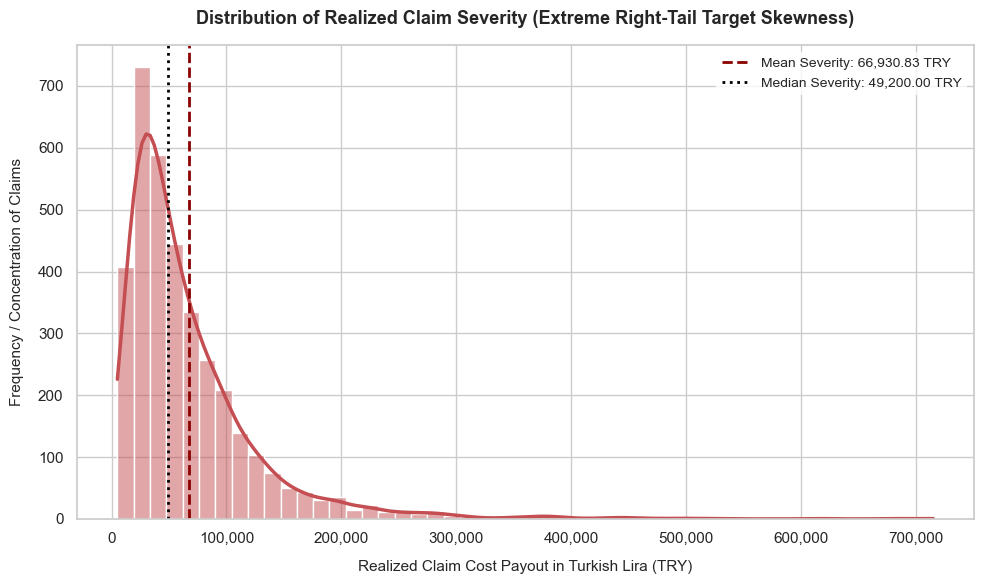

In [25]:
##silenecek
claimant_df = df[df['had_claim'] == 1]
mean_cost = claimant_df['claim_cost_TRY'].mean()
median_cost = claimant_df['claim_cost_TRY'].median()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=claimant_df, 
    x='claim_cost_TRY', 
    kde=True, 
    bins=50, 
    color='#c44e52', 
    line_kws={'linewidth': 2.5}
)
plt.axvline(mean_cost, color='darkred', linestyle='--', linewidth=2, 
            label=f'Mean Severity: {mean_cost:,.2f} TRY')
plt.axvline(median_cost, color='black', linestyle=':', linewidth=2, 
            label=f'Median Severity: {median_cost:,.2f} TRY')
plt.title('Distribution of Realized Claim Severity (Extreme Right-Tail Target Skewness)', 
          fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Realized Claim Cost Payout in Turkish Lira (TRY)', fontsize=11, labelpad=10)
plt.ylabel('Frequency / Concentration of Claims', fontsize=11, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend(fontsize=10, loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.savefig('claim_severity_right_tail_skewness.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\dolap\AppData\Local\Temp\ipykernel_26768\2007592231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=last_ten.values,y=last_ten.index,palette='Reds_r')


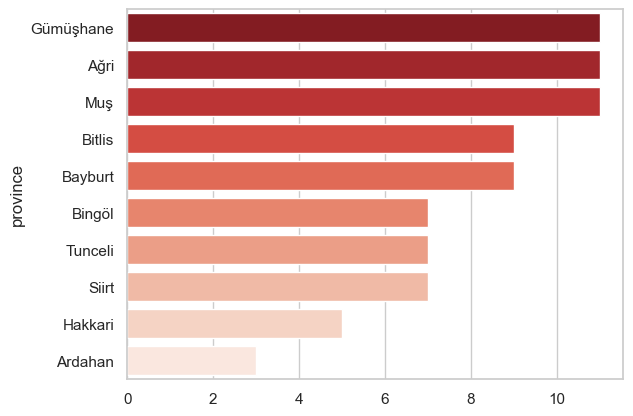

In [26]:
figsize=(15,15)
sns.barplot(x=last_ten.values,y=last_ten.index,palette='Reds_r')
plt.show()

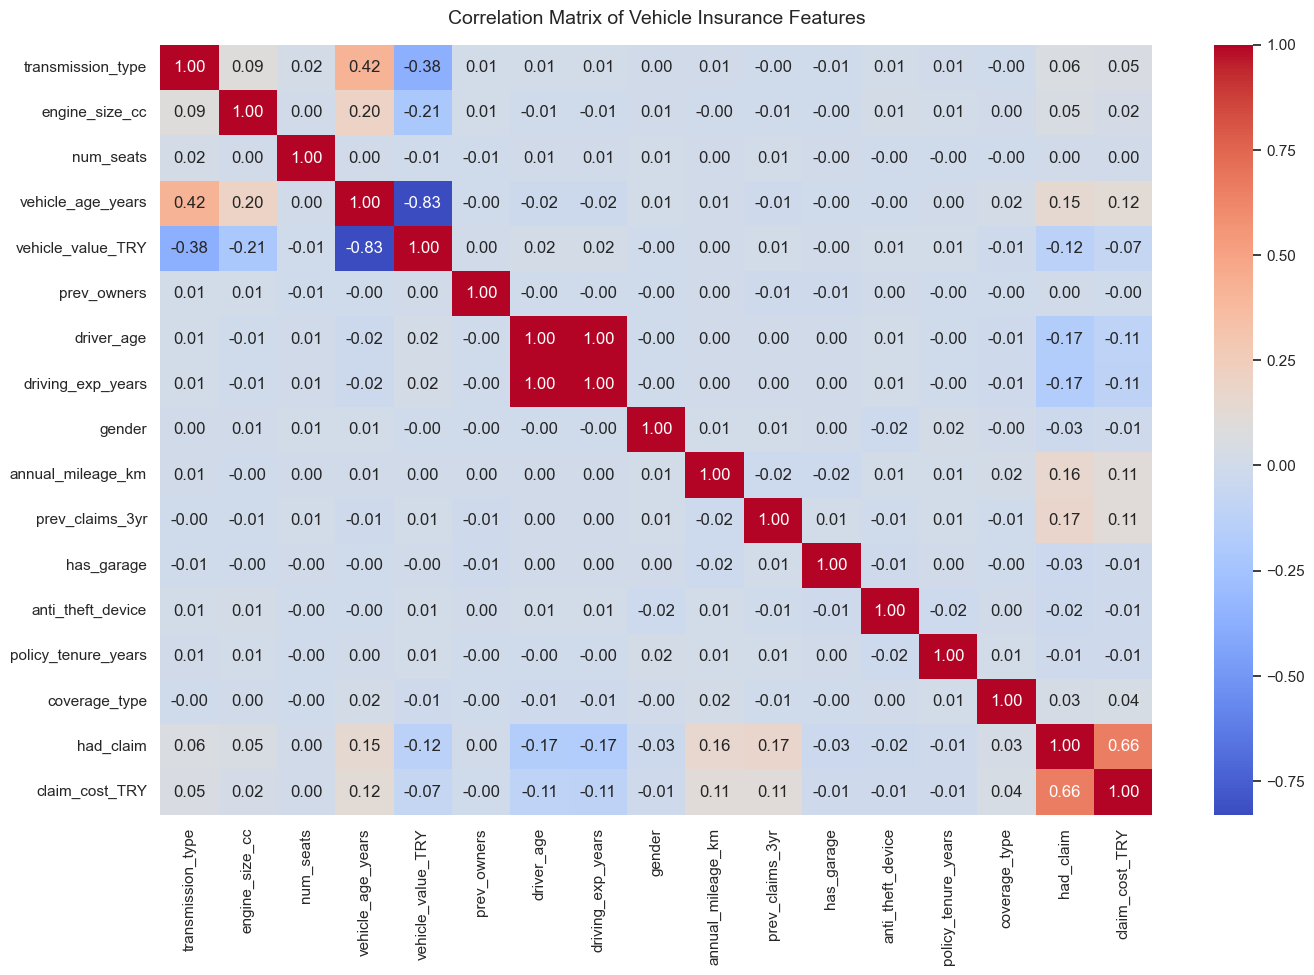

<Figure size 640x480 with 0 Axes>

In [27]:
#silenecek
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Vehicle Insurance Features', fontsize=14, pad=15)
plt.savefig('correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.savefig('had_claim_zero_inflation_countplot.png', dpi=300, bbox_inches='tight')
plt.show()

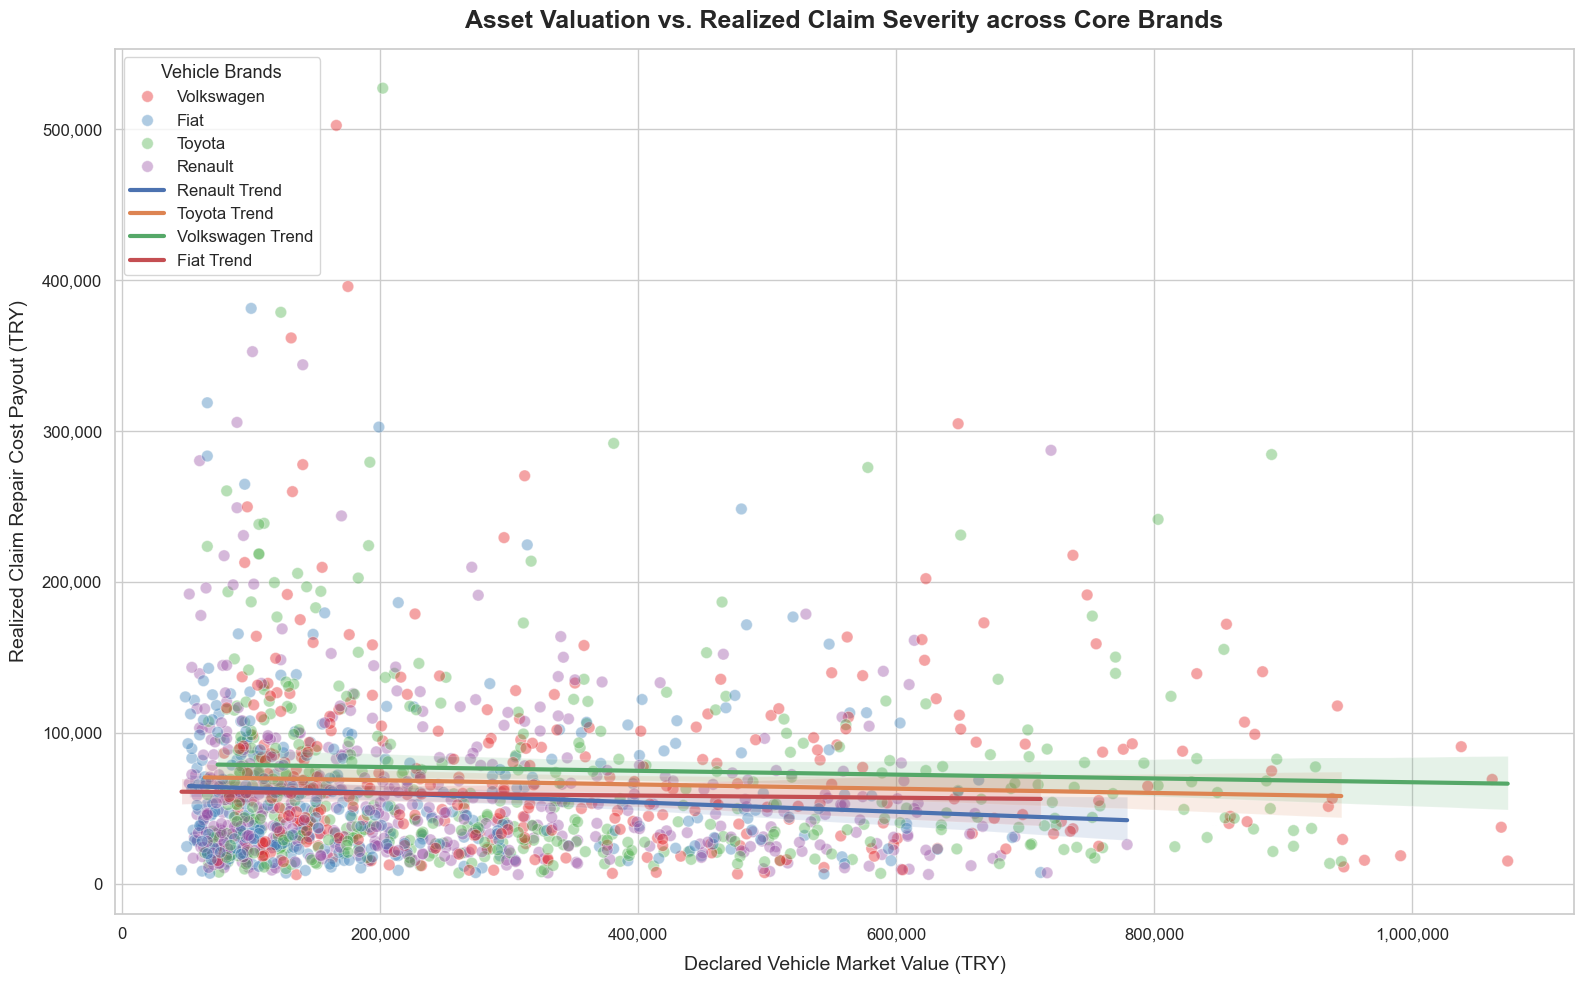

In [28]:
#silenecek
claimant_df = df[df['had_claim'] == 1].copy()
top_brands = ['Renault', 'Toyota', 'Volkswagen', 'Fiat']
filtered_df = claimant_df[claimant_df['brand'].isin(top_brands)].copy()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x=filtered_df['vehicle_value_TRY'],
    y=filtered_df['claim_cost_TRY'],
    hue=filtered_df['brand'],
    palette='Set1',
    alpha=0.4,
    s=70
)
for brand in top_brands:
    brand_data = filtered_df[filtered_df['brand'] == brand]
    sns.regplot(
        x=brand_data['vehicle_value_TRY'],
        y=brand_data['claim_cost_TRY'],
        scatter=False,  # Don't redraw the individual points
        label=f'{brand} Trend',
        line_kws={'linewidth': 3}  # <--- FIX: Wrapped inside line_kws dictionary!
    )
plt.title('Asset Valuation vs. Realized Claim Severity across Core Brands', fontsize=18, pad=15, fontweight='bold')
plt.xlabel('Declared Vehicle Market Value (TRY)', fontsize=14, labelpad=10)
plt.ylabel('Realized Claim Repair Cost Payout (TRY)', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend(fontsize=12, title='Vehicle Brands', title_fontsize=13, loc='upper left')
plt.tight_layout()
plt.savefig('asset_value_vs_brand_repair_mechanics.png', dpi=400, bbox_inches='tight')
plt.show()

In [31]:
heat_map_source=df.corr(numeric_only=True)

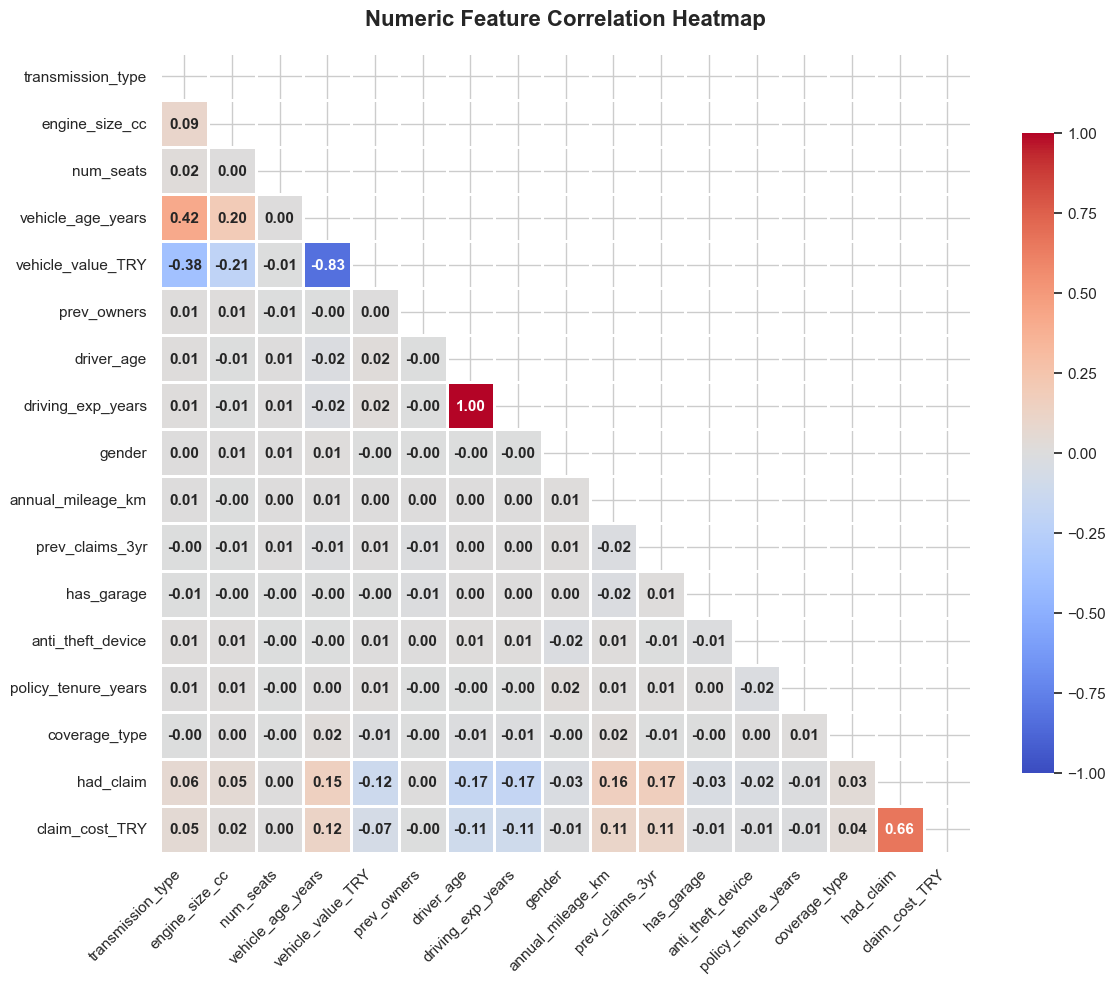

In [32]:

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(heat_map_source, dtype=bool))
sns.heatmap(
    heat_map_source, 
    mask=mask,               
    annot=True,              
    fmt=".2f",               
    cmap='coolwarm',         
    vmin=-1, vmax=1,        
    center=0,                
    linewidths=1,            
    annot_kws={"size": 11, "weight": "bold"},  
    cbar_kws={"shrink": 0.8} 
)
plt.title('Numeric Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.yticks(rotation=0, fontsize=11)              
plt.tight_layout()
plt.show()

In [33]:
#I see that there is brand named other and model named various, I will check how many of them are in the dataset
df[df['brand']=='Other']['model'].value_counts()

model
Various    346
Name: count, dtype: int64

In [34]:
#as the number 346 is pretty small in all dataset, I will drop them: 
df_cleaned=df[df['brand']!='Other']

In [35]:
#in order to check others removed from dataset I will use value counts
df_cleaned['brand'].value_counts()

brand
Renault       1296
Toyota        1226
Volkswagen     894
Hyundai        835
Fiat           829
Ford           748
Dacia          725
Peugeot        619
Opel           465
Citroen        361
BMW            357
Mercedes       352
Togg           301
Skoda          272
Kia            206
Honda          168
Name: count, dtype: int64

In [36]:
X=df_cleaned.drop(['had_claim','claim_cost_TRY'],axis=1)
y_class=df_cleaned['had_claim']
y_reg=df_cleaned['claim_cost_TRY']

In [37]:
X_train,X_test,y_class_train,y_class_test,y_reg_train,y_reg_test=train_test_split(X,y_class,y_reg,test_size=0.3,random_state=15)

In [38]:
X_train['brand'].value_counts()

brand
Renault       914
Toyota        863
Volkswagen    602
Hyundai       592
Fiat          581
Ford          515
Dacia         508
Peugeot       442
Opel          335
BMW           257
Citroen       245
Mercedes      228
Togg          206
Skoda         191
Kia           157
Honda         121
Name: count, dtype: int64

In [39]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6757 entries, 9179 to 7889
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               6757 non-null   object
 1   brand                  6757 non-null   object
 2   model                  6757 non-null   object
 3   fuel_type              6757 non-null   object
 4   transmission_type      6757 non-null   int64 
 5   engine_size_cc         6757 non-null   int64 
 6   num_seats              6757 non-null   int64 
 7   vehicle_type           6757 non-null   object
 8   vehicle_age_years      6757 non-null   int64 
 9   vehicle_value_TRY      6757 non-null   int64 
 10  prev_owners            6757 non-null   int64 
 11  vehicle_usage_purpose  6757 non-null   object
 12  usage_type             6757 non-null   object
 13  driver_age             6757 non-null   int64 
 14  driving_exp_years      6757 non-null   int64 
 15  gender                 

In [40]:
X_train['brand_model']=X_train['brand'].astype('str')+'_'+X_train['model'].astype('str')
X_test['brand_model']=X_test['brand'].astype('str')+'_'+X_test['model'].astype('str')
X_train.drop(['brand','model'],axis=1,inplace=True)
X_test.drop(['brand','model'],axis=1,inplace=True)

In [41]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6757 entries, 9179 to 7889
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               6757 non-null   object
 1   fuel_type              6757 non-null   object
 2   transmission_type      6757 non-null   int64 
 3   engine_size_cc         6757 non-null   int64 
 4   num_seats              6757 non-null   int64 
 5   vehicle_type           6757 non-null   object
 6   vehicle_age_years      6757 non-null   int64 
 7   vehicle_value_TRY      6757 non-null   int64 
 8   prev_owners            6757 non-null   int64 
 9   vehicle_usage_purpose  6757 non-null   object
 10  usage_type             6757 non-null   object
 11  driver_age             6757 non-null   int64 
 12  driving_exp_years      6757 non-null   int64 
 13  gender                 6757 non-null   int64 
 14  annual_mileage_km      6757 non-null   int64 
 15  prev_claims_3yr        

In [42]:
X_train_columns=X_train.columns.tolist()

In [43]:
categorical_cols=X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}")
    print(X_train[col].unique())

province
['Afyonkarahisar' 'Kocaeli' 'Antalya' 'Hatay' 'İzmir' 'Mersin' 'Manisa'
 'Isparta' 'Erzurum' 'Malatya' 'Niğde' 'Yalova' 'İstanbul' 'Amasya'
 'Konya' 'Balikesir' 'Muğla' 'Ankara' 'Gaziantep' 'Aydin' 'Burdur' 'Bursa'
 'Bingöl' 'Kirklareli' 'Mardin' 'Diyarbakir' 'Sakarya' 'Karaman' 'Samsun'
 'Denizli' 'Iğdir' 'Van' 'Eskişehir' 'Çanakkale' 'Bolu' 'Trabzon'
 'Erzincan' 'Tekirdağ' 'Ordu' 'Tokat' 'Elaziğ' 'Edirne' 'Nevşehir'
 'Aksaray' 'Çorum' 'Kastamonu' 'Kahramanmaraş' 'Adana' 'Kayseri'
 'Osmaniye' 'Adiyaman' 'Kütahya' 'Uşak' 'Düzce' 'Çankiri' 'Şanliurfa'
 'Kirikkale' 'Batman' 'Yozgat' 'Zonguldak' 'Tunceli' 'Karabük' 'Sinop'
 'Gümüşhane' 'Bayburt' 'Kilis' 'Ardahan' 'Bartin' 'Artvin' 'Kirşehir'
 'Sivas' 'Muş' 'Giresun' 'Şirnak' 'Rize' 'Siirt' 'Hakkari' 'Bilecik'
 'Kars' 'Ağri' 'Bitlis']
fuel_type
['Gasoline' 'Hybrid' 'LPG' 'Diesel' 'Electric']
vehicle_type
['SUV' 'Hatchback' 'Sedan' 'Small Truck' 'Minibus']
vehicle_usage_purpose
['Private' 'Company Fleet' 'Rental' 'Taxi' 'Cargo/Cour

In [44]:
ordered_categories=X_train.groupby(['brand_model'])['vehicle_value_TRY'].mean().sort_values().index.tolist()
car_order_list=X_train.groupby(['province'])['vehicle_value_TRY'].count().sort_values().index.tolist()
categorial_columns=['fuel_type','vehicle_type','vehicle_usage_purpose','usage_type','brand_model','province']
ordinal_encoder=OrdinalEncoder(categories=[
                                            X_train['fuel_type'].unique().tolist(),
                                            X_train['vehicle_type'].unique().tolist(),
                                            X_train['vehicle_usage_purpose'].unique().tolist(),
                                            X_train['usage_type'].unique().tolist(),
                                            ordered_categories,
                                            car_order_list
                                          ])

In [45]:
preprocessor=ColumnTransformer(transformers=[('transformer',ordinal_encoder,categorial_columns)],remainder='passthrough',verbose_feature_names_out=False)

In [46]:
preprocessor.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('transformer',
                                 OrdinalEncoder(categories=[['Gasoline',
                                                             'Hybrid', 'LPG',
                                                             'Diesel',
                                                             'Electric'],
                                                            ['SUV', 'Hatchback',
                                                             'Sedan',
                                                             'Small Truck',
                                                             'Minibus'],
                                                            ['Private',
                                                             'Company Fleet',
                                                             'Rental', 'Taxi',
                                                             'Cargo/Courier',
                                                             'Driving School'],
                                                            ['Rural', 'Urban',
                                                             'Mixed'],
                                                            ['Dacia_Duster',
                                                             'Dacia_Logan',
                                                             'Dacia_Jogger',
                                                             'Dacia_...
                                                             'Gümüşhane',
                                                             'Bayburt',
                                                             'Tunceli', 'Kars',
                                                             'Ağri', 'Muş',
                                                             'Iğdir', 'Şirnak',
                                                             'Bilecik',
                                                             'Artvin', 'Bartin',
                                                             'Sinop',
                                                             'Kirşehir',
                                                             'Kilis', 'Rize',
                                                             'Kirikkale',
                                                             'Çankiri',
                                                             'Batman',
                                                             'Erzincan',
                                                             'Karaman',
                                                             'Yalova',
                                                             'Giresun',
                                                             'Karabük', 'Van',
                                                             'Yozgat', ...]]),
                                 ['fuel_type', 'vehicle_type',
                                  'vehicle_usage_purpose', 'usage_type',
                                  'brand_model', 'province'])],
                  verbose_feature_names_out=False)

In [47]:
X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

In [48]:
X_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2897 entries, 8316 to 5313
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fuel_type              2897 non-null   float64
 1   vehicle_type           2897 non-null   float64
 2   vehicle_usage_purpose  2897 non-null   float64
 3   usage_type             2897 non-null   float64
 4   brand_model            2897 non-null   float64
 5   province               2897 non-null   float64
 6   transmission_type      2897 non-null   int64  
 7   engine_size_cc         2897 non-null   int64  
 8   num_seats              2897 non-null   int64  
 9   vehicle_age_years      2897 non-null   int64  
 10  vehicle_value_TRY      2897 non-null   int64  
 11  prev_owners            2897 non-null   int64  
 12  driver_age             2897 non-null   int64  
 13  driving_exp_years      2897 non-null   int64  
 14  gender                 2897 non-null   int64  
 15  annual

In [49]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6757 entries, 9179 to 7889
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fuel_type              6757 non-null   float64
 1   vehicle_type           6757 non-null   float64
 2   vehicle_usage_purpose  6757 non-null   float64
 3   usage_type             6757 non-null   float64
 4   brand_model            6757 non-null   float64
 5   province               6757 non-null   float64
 6   transmission_type      6757 non-null   int64  
 7   engine_size_cc         6757 non-null   int64  
 8   num_seats              6757 non-null   int64  
 9   vehicle_age_years      6757 non-null   int64  
 10  vehicle_value_TRY      6757 non-null   int64  
 11  prev_owners            6757 non-null   int64  
 12  driver_age             6757 non-null   int64  
 13  driving_exp_years      6757 non-null   int64  
 14  gender                 6757 non-null   int64  
 15  annual

In [50]:
X_train_encoded.head(5)

,fuel_type,vehicle_type,vehicle_usage_purpose,usage_type,brand_model,province,transmission_type,engine_size_cc,num_seats,vehicle_age_years,...,prev_owners,driver_age,driving_exp_years,gender,annual_mileage_km,prev_claims_3yr,has_garage,anti_theft_device,policy_tenure_years,coverage_type
9179,0.0,0.0,0.0,0.0,63.0,59.0,0,1575,5,4,...,2,43,25,1,77890,1,1,0,15,0
856,0.0,0.0,0.0,1.0,44.0,67.0,0,1556,5,21,...,2,47,25,1,51806,1,0,0,5,1
4426,0.0,0.0,0.0,1.0,55.0,77.0,0,1281,7,9,...,0,23,1,1,8687,0,0,1,15,0
6599,1.0,1.0,0.0,1.0,23.0,68.0,1,1578,5,5,...,1,36,18,1,63754,0,1,0,15,1
3107,2.0,0.0,0.0,1.0,58.0,78.0,0,1602,7,14,...,0,35,17,0,29028,0,0,0,12,0


In [51]:
X_train['brand_model'].head(5)

9179        Togg_T10F
856       Peugeot_208
4426      Toyota_RAV4
6599    Skoda_Octavia
3107      Hyundai_i20
Name: brand_model, dtype: object

In [52]:
X_train_encoded.corr()

,fuel_type,vehicle_type,vehicle_usage_purpose,usage_type,brand_model,province,transmission_type,engine_size_cc,num_seats,vehicle_age_years,...,prev_owners,driver_age,driving_exp_years,gender,annual_mileage_km,prev_claims_3yr,has_garage,anti_theft_device,policy_tenure_years,coverage_type
fuel_type,1.000000,0.001138,0.010888,0.025825,-0.007339,-0.005075,0.014300,0.038809,-0.014818,0.027193,...,0.007610,-0.005338,-0.005400,-0.000467,-0.008987,0.003002,0.009485,0.001096,-0.003191,-0.020962
vehicle_type,0.001138,1.000000,-0.000954,-0.007996,0.007774,0.001960,0.000443,0.008743,-0.172611,0.006891,...,-0.002193,0.018718,0.018152,-0.002319,0.022834,-0.000660,-0.007578,-0.007226,0.011922,0.007297
vehicle_usage_purpose,0.010888,-0.000954,1.000000,0.002154,0.003107,-0.000551,0.001068,0.028892,0.003269,0.007238,...,0.001481,0.014238,0.012793,-0.027401,0.006724,-0.012578,0.006624,0.012543,-0.019488,0.008333
usage_type,0.025825,-0.007996,0.002154,1.000000,-0.008618,-0.011613,0.011737,0.013591,0.001833,-0.003436,...,0.004260,-0.011565,-0.011609,-0.019250,0.005580,0.001714,0.007553,0.014040,-0.005774,0.001253
brand_model,-0.007339,0.007774,0.003107,-0.008618,1.000000,-0.011413,-0.011211,-0.001357,0.013872,-0.029580,...,0.020275,0.028947,0.028361,-0.002709,0.008917,-0.012680,-0.011771,0.007603,0.002673,-0.020274
province,-0.005075,0.001960,-0.000551,-0.011613,-0.011413,1.000000,-0.008746,-0.006901,0.018230,-0.012120,...,0.001506,-0.001613,0.000467,-0.011427,-0.001398,-0.001706,-0.005730,-0.005088,0.014960,0.003707
transmission_type,0.014300,0.000443,0.001068,0.011737,-0.011211,-0.008746,1.000000,0.091648,0.020995,0.408008,...,0.002835,0.008747,0.009662,0.001115,0.011174,-0.001328,-0.011657,0.007920,0.003565,0.004154
engine_size_cc,0.038809,0.008743,0.028892,0.013591,-0.001357,-0.006901,0.091648,1.000000,-0.000220,0.205672,...,0.012237,-0.004193,-0.003900,0.009153,0.009819,-0.009481,0.001895,0.019035,0.014203,0.002071
num_seats,-0.014818,-0.172611,0.003269,0.001833,0.013872,0.018230,0.020995,-0.000220,1.000000,0.012888,...,-0.006801,0.010164,0.010269,0.013581,0.000125,-0.000164,0.000857,-0.010656,-0.008358,0.001521
vehicle_age_years,0.027193,0.006891,0.007238,-0.003436,-0.029580,-0.012120,0.408008,0.205672,0.012888,1.000000,...,0.001089,-0.036812,-0.036512,0.011154,0.016455,0.001832,0.002170,-0.002725,-0.010614,0.024384


In [53]:
X_test_encoded.corr()

,fuel_type,vehicle_type,vehicle_usage_purpose,usage_type,brand_model,province,transmission_type,engine_size_cc,num_seats,vehicle_age_years,...,prev_owners,driver_age,driving_exp_years,gender,annual_mileage_km,prev_claims_3yr,has_garage,anti_theft_device,policy_tenure_years,coverage_type
fuel_type,1.000000,0.043605,-0.013027,-0.024012,0.014009,-0.020769,0.041850,0.047619,-0.000341,0.043172,...,0.021959,-0.000266,-0.002189,-0.008805,-0.004260,0.033480,-0.020755,-0.004798,-0.005160,0.010358
vehicle_type,0.043605,1.000000,0.016695,-0.004848,-0.036803,-0.006673,0.005030,-0.019410,-0.195970,-0.000551,...,0.017538,-0.009030,-0.006745,-0.022525,0.016553,-0.018225,-0.027437,-0.015152,-0.002266,0.007700
vehicle_usage_purpose,-0.013027,0.016695,1.000000,-0.009580,-0.012367,-0.004179,0.000590,-0.003141,0.004847,0.019083,...,0.036392,-0.017658,-0.021327,0.009303,0.007310,-0.012572,-0.006593,0.009329,-0.004376,-0.008133
usage_type,-0.024012,-0.004848,-0.009580,1.000000,0.029158,-0.007471,-0.030991,-0.033763,0.005306,-0.003382,...,0.015253,0.010499,0.013667,-0.007726,-0.017121,0.001798,0.005099,0.020097,0.003232,-0.016197
brand_model,0.014009,-0.036803,-0.012367,0.029158,1.000000,0.015644,-0.018848,0.011612,-0.015204,-0.008755,...,-0.001267,-0.014924,-0.017245,0.031221,-0.025641,-0.027413,-0.026769,0.026532,0.004513,0.020066
province,-0.020769,-0.006673,-0.004179,-0.007471,0.015644,1.000000,0.005208,0.020628,0.000131,-0.010830,...,-0.025807,0.015126,0.012941,-0.015678,0.013143,-0.018515,-0.009915,-0.010904,-0.023764,0.019634
transmission_type,0.041850,0.005030,0.000590,-0.030991,-0.018848,0.005208,1.000000,0.093655,0.000442,0.425128,...,0.026384,0.011143,0.012079,-0.002491,-0.008198,-0.007575,-0.002358,0.015324,0.008331,-0.019199
engine_size_cc,0.047619,-0.019410,-0.003141,-0.033763,0.011612,0.020628,0.093655,1.000000,-0.000551,0.180246,...,0.003910,-0.007660,-0.006053,-0.010137,-0.025515,0.003896,-0.009031,-0.003919,-0.002134,-0.000781
num_seats,-0.000341,-0.195970,0.004847,0.005306,-0.015204,0.000131,0.000442,-0.000551,1.000000,-0.025651,...,-0.010629,-0.013747,-0.010947,0.005653,-0.009819,0.025617,0.003302,0.006264,0.008303,-0.003957
vehicle_age_years,0.043172,-0.000551,0.019083,-0.003382,-0.008755,-0.010830,0.425128,0.180246,-0.025651,1.000000,...,-0.011830,0.014670,0.013841,0.002598,-0.016894,-0.028983,-0.013293,-0.013582,0.027712,0.008644


In [54]:
def correlation_for_dropping(df,threshold):
    columns_to_drop=set()
    corr=df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j])>threshold:
                colname=corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop    

In [55]:
correlation_for_dropping(X_train_encoded,0.8)

{'driving_exp_years', 'vehicle_value_TRY'}

In [56]:
X_train_encoded=X_train_encoded.drop(['vehicle_age_years','driver_age'],axis=1)
X_test_encoded=X_test_encoded.drop(['vehicle_age_years','driver_age'],axis=1)

In [57]:
def find_outliner_iqr(df,threshold=1.5):
    outlier_summary={}
    numeric_cols=df.select_dtypes(include=["float64",'int64']).columns
    categorical_cols=df.select_dtypes(include=['object']).columns
    for col in numeric_cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        
        lower_bound=Q1-threshold*IQR
        upper_bound=Q3+threshold*IQR
        
        outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
        outlier_summary[col]={
            'outlier_count':outliers.shape[0],
            'outlier_percentage':100 * outliers.shape[0]/df.shape[0],
            'lower_bound':lower_bound,
            'upper_bound':upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [58]:
find_outliner_iqr(df_cleaned,1.5)

,transmission_type,engine_size_cc,num_seats,vehicle_age_years,vehicle_value_TRY,prev_owners,driver_age,driving_exp_years,gender,annual_mileage_km,prev_claims_3yr,has_garage,anti_theft_device,policy_tenure_years,coverage_type,had_claim,claim_cost_TRY
outlier_count,0.0,413.000000,1723.000000,0.0,167.000000,0.0,0.0,0.0,0.0,0.00,468.000000,0.0,0.0,0.0,0.0,0.0,963.00000
outlier_percentage,0.0,4.278019,17.847524,0.0,1.729853,0.0,0.0,0.0,0.0,0.00,4.847732,0.0,0.0,0.0,0.0,0.0,9.97514
lower_bound,-1.5,769.875000,5.000000,-18.0,-383500.000000,-3.0,-11.5,-31.5,-1.5,-33614.25,-1.500000,-1.5,-1.5,-8.0,-1.5,-1.5,-47850.00000
upper_bound,2.5,2196.875000,5.000000,46.0,996500.000000,5.0,104.5,84.5,2.5,118895.75,2.500000,2.5,2.5,24.0,2.5,2.5,79750.00000


In [59]:
correlation_for_dropping(X_train_encoded,0.8)

set()

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   province               10000 non-null  object
 1   brand                  10000 non-null  object
 2   model                  10000 non-null  object
 3   fuel_type              10000 non-null  object
 4   transmission_type      10000 non-null  int64 
 5   engine_size_cc         10000 non-null  int64 
 6   num_seats              10000 non-null  int64 
 7   vehicle_type           10000 non-null  object
 8   vehicle_age_years      10000 non-null  int64 
 9   vehicle_value_TRY      10000 non-null  int64 
 10  prev_owners            10000 non-null  int64 
 11  vehicle_usage_purpose  10000 non-null  object
 12  usage_type             10000 non-null  object
 13  driver_age             10000 non-null  int64 
 14  driving_exp_years      10000 non-null  int64 
 15  gender              

In [61]:
colums_to_be_scaled=['brand_model','province','vehicle_value_TRY',
                     'prev_claims_3yr','fuel_type','vehicle_type','vehicle_usage_purpose',
                     'usage_type','engine_size_cc','num_seats','prev_owners','driving_exp_years','annual_mileage_km','policy_tenure_years',
                    ]

In [62]:
X_train_encoded.columns

Index(['fuel_type', 'vehicle_type', 'vehicle_usage_purpose', 'usage_type',
       'brand_model', 'province', 'transmission_type', 'engine_size_cc',
       'num_seats', 'vehicle_value_TRY', 'prev_owners', 'driving_exp_years',
       'gender', 'annual_mileage_km', 'prev_claims_3yr', 'has_garage',
       'anti_theft_device', 'policy_tenure_years', 'coverage_type'],
      dtype='object')

In [63]:
X_train_encoded['coverage_type'].value_counts()

coverage_type
1    3873
0    2884
Name: count, dtype: int64

In [64]:
robust=ColumnTransformer(transformers=[('Robust',RobustScaler(),colums_to_be_scaled)],remainder='passthrough',verbose_feature_names_out=False)

In [65]:
robust.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('Robust', RobustScaler(),
                                 ['brand_model', 'province',
                                  'vehicle_value_TRY', 'prev_claims_3yr',
                                  'fuel_type', 'vehicle_type',
                                  'vehicle_usage_purpose', 'usage_type',
                                  'engine_size_cc', 'num_seats', 'prev_owners',
                                  'driving_exp_years', 'annual_mileage_km',
                                  'policy_tenure_years'])],
                  verbose_feature_names_out=False)

In [66]:
X_train_transformed=robust.fit_transform(X_train_encoded)
X_test_transformed=robust.transform(X_test_encoded)

In [67]:
X_train_transformed.apply(skew).sort_values(ascending=False)

num_seats                1.778069
vehicle_usage_purpose    1.514011
prev_claims_3yr          1.485036
vehicle_value_TRY        1.362132
vehicle_type             1.175941
prev_owners              0.882270
transmission_type        0.482608
fuel_type                0.461317
gender                   0.212827
policy_tenure_years      0.019073
annual_mileage_km        0.000882
brand_model             -0.013775
driving_exp_years       -0.071752
usage_type              -0.142754
coverage_type           -0.295920
has_garage              -0.406864
anti_theft_device       -0.573664
province                -1.539054
engine_size_cc          -1.833870
dtype: float64

In [68]:
X_train_encoded.apply(skew).sort_values(ascending=False)

num_seats                1.778069
vehicle_usage_purpose    1.514011
prev_claims_3yr          1.485036
vehicle_value_TRY        1.362132
vehicle_type             1.175941
prev_owners              0.882270
transmission_type        0.482608
fuel_type                0.461317
gender                   0.212827
policy_tenure_years      0.019073
annual_mileage_km        0.000882
brand_model             -0.013775
driving_exp_years       -0.071752
usage_type              -0.142754
coverage_type           -0.295920
has_garage              -0.406864
anti_theft_device       -0.573664
province                -1.539054
engine_size_cc          -1.833870
dtype: float64

In [69]:
colums_to_be_powered=['vehicle_value_TRY',
                     'prev_claims_3yr','engine_size_cc','num_seats',
                     'prev_owners','driving_exp_years','annual_mileage_km','policy_tenure_years',
                    ]

In [70]:
poweroverhelming=ColumnTransformer(transformers=[
    ('power' ,PowerTransformer(method='yeo-johnson',standardize=True),colums_to_be_powered,
    )],remainder='passthrough',verbose_feature_names_out=False)
poweroverhelming.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('power', PowerTransformer(),
                                 ['vehicle_value_TRY', 'prev_claims_3yr',
                                  'engine_size_cc', 'num_seats', 'prev_owners',
                                  'driving_exp_years', 'annual_mileage_km',
                                  'policy_tenure_years'])],
                  verbose_feature_names_out=False)

In [71]:
X_train_transformed=poweroverhelming.fit_transform(X_train_transformed)
X_test_transformed=poweroverhelming.transform(X_test_transformed)

In [72]:
X_train_transformed.apply(skew).sort_values(ascending=False)

vehicle_usage_purpose    1.514011
vehicle_type             1.175941
transmission_type        0.482608
prev_claims_3yr          0.473041
fuel_type                0.461317
engine_size_cc           0.272187
gender                   0.212827
vehicle_value_TRY        0.144398
prev_owners              0.136167
policy_tenure_years      0.004746
annual_mileage_km       -0.000068
brand_model             -0.013775
driving_exp_years       -0.015145
usage_type              -0.142754
coverage_type           -0.295920
has_garage              -0.406864
anti_theft_device       -0.573664
num_seats               -0.581099
province                -1.539054
dtype: float64

In [73]:
def evaluate_model_class(true, predicted, predicted_probs=None):
    confusion_mtrx = confusion_matrix(true, predicted)
    accuracy_result = accuracy_score(true, predicted)
    class_report = classification_report(true, predicted)
    roc_auc = None
    if predicted_probs is not None:
        roc_auc = roc_auc_score(true, predicted_probs)
        
    return accuracy_result, confusion_mtrx, class_report, roc_auc

In [74]:
####classifaction modelleri#####
class_models = {
    'Logistic Regression': LogisticRegression(), 
    'Naive Bayes': GaussianNB(),
    'Ridge Classifier': RidgeClassifier(),
    'K Neighbors Classifier': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest Classifier': RandomForestClassifier(n_jobs=-1), 
    'Adaboost Classifier': AdaBoostClassifier(),
    'GradientBoost Classifier': GradientBoostingClassifier(),
    'XGBoost Classifier': XGBClassifier(n_jobs=-1),
    'LGBM Classifier': LGBMClassifier(verbosity=-1, n_jobs=-1)
}
    
for name, model in class_models.items():
    print(f"Training {name}...")
    model.fit(X_train_transformed, y_class_train)
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train_transformed)[:, 1]
        y_test_prob = model.predict_proba(X_test_transformed)[:, 1]
    elif hasattr(model, "decision_function"):
        y_train_prob = model.decision_function(X_train_transformed)
        y_test_prob = model.decision_function(X_test_transformed)
    else:
        y_train_prob = None
        y_test_prob = None
    
    acc_train, conf_train, class_rep_train, auc_train = evaluate_model_class(y_class_train, y_train_pred, y_train_prob)
    acc_test, conf_test, class_rep_test, auc_test = evaluate_model_class(y_class_test, y_test_pred, y_test_prob)
    
    print(f"--- {name} Performance ---")
    

    if auc_train is not None:
        print(f"TRAIN | Accuracy: {acc_train:.4f} | ROC-AUC: {auc_train:.4f}")
        print(f"TEST  | Accuracy: {acc_test:.4f}  | ROC-AUC: {auc_test:.4f}")
    else:
        print(f"TRAIN | Accuracy: {acc_train:.4f} | ROC-AUC: N/A")
        print(f"TEST  | Accuracy: {acc_test:.4f}  | ROC-AUC: N/A")
        
    print("\nTest Confusion Matrix:")
    print(conf_test)
    print("\nTest Classification Report:")
    print(class_rep_test)
    print("="*50 + "\n")

Training Logistic Regression...
--- Logistic Regression Performance ---
TRAIN | Accuracy: 0.6871 | ROC-AUC: 0.7014
TEST  | Accuracy: 0.6842  | ROC-AUC: 0.6933

Test Confusion Matrix:
[[1670  200]
 [ 715  312]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78      1870
           1       0.61      0.30      0.41      1027

    accuracy                           0.68      2897
   macro avg       0.65      0.60      0.60      2897
weighted avg       0.67      0.68      0.65      2897


Training Naive Bayes...
--- Naive Bayes Performance ---
TRAIN | Accuracy: 0.6840 | ROC-AUC: 0.6986
TEST  | Accuracy: 0.6931  | ROC-AUC: 0.6949

Test Confusion Matrix:
[[1644  226]
 [ 663  364]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79      1870
           1       0.62      0.35      0.45      1027

    accuracy                           0.69   

C:\Users\dolap\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\dolap\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dolap\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dolap\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

--- K Neighbors Classifier Performance ---
TRAIN | Accuracy: 0.7457 | ROC-AUC: 0.8054
TEST  | Accuracy: 0.6496  | ROC-AUC: 0.6187

Test Confusion Matrix:
[[1520  350]
 [ 665  362]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.81      0.75      1870
           1       0.51      0.35      0.42      1027

    accuracy                           0.65      2897
   macro avg       0.60      0.58      0.58      2897
weighted avg       0.63      0.65      0.63      2897


Training Decision Tree Classifier...
--- Decision Tree Classifier Performance ---
TRAIN | Accuracy: 1.0000 | ROC-AUC: 1.0000
TEST  | Accuracy: 0.5806  | ROC-AUC: 0.5454

Test Confusion Matrix:
[[1246  624]
 [ 591  436]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      1870
           1       0.41      0.42      0.42      1027

    accuracy                           0.58      

In [75]:
#silenecek
# 1. Re-defining your exact 10 classification models dictionary from Cell 71
class_models = {
    'Logistic Regression': LogisticRegression(), 
    'Naive Bayes': GaussianNB(),
    'Ridge Classifier': RidgeClassifier(),
    'K Neighbors Classifier': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest Classifier': RandomForestClassifier(n_jobs=-1), 
    'Adaboost Classifier': AdaBoostClassifier(),
    'GradientBoost Classifier': GradientBoostingClassifier(),
    'XGBoost Classifier': XGBClassifier(n_jobs=-1),
    'LGBM Classifier': LGBMClassifier(verbosity=-1, n_jobs=-1)
}

# 2. Print Markdown Table Headers
print("| Model | Train Acc. | Test Acc. | Train AUC | Test AUC |")
print("| :--- | :---: | :---: | :---: | :---: |")

# 3. Fit, Predict, and Print Metrics for each model sequentially
for name, model in class_models.items():
    # Train the model
    model.fit(X_train_transformed, y_class_train)
    
    # Generate predictions
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)
    
    # Calculate Accuracy
    acc_train = accuracy_score(y_class_train, y_train_pred)
    acc_test = accuracy_score(y_class_test, y_test_pred)
    
    # Calculate ROC-AUC probabilities
    if hasattr(model, "predict_proba"):
        auc_train = roc_auc_score(y_class_train, model.predict_proba(X_train_transformed)[:, 1])
        auc_test = roc_auc_score(y_class_test, model.predict_proba(X_test_transformed)[:, 1])
        auc_train_str = f"{auc_train:.4f}"
        auc_test_str = f"{auc_test:.4f}"
    elif hasattr(model, "decision_function"):
        auc_train = roc_auc_score(y_class_train, model.decision_function(X_train_transformed))
        auc_test = roc_auc_score(y_class_test, model.decision_function(X_test_transformed))
        auc_train_str = f"{auc_train:.4f}"
        auc_test_str = f"{auc_test:.4f}"
    else:
        auc_train_str = "N/A"
        auc_test_str = "N/A"
        
    # Apply bold text and checkmark to your final selected thesis model
    if name == 'GradientBoost Classifier':
        display_name = "**Gradient Boosting ✓**"
    else:
        display_name = name
    
    # Print out the clean markdown row
    print(f"| {display_name} | {acc_train:.4f} | {acc_test:.4f} | {auc_train_str} | {auc_test_str} |")

| Model | Train Acc. | Test Acc. | Train AUC | Test AUC |
| :--- | :---: | :---: | :---: | :---: |
| Logistic Regression | 0.6871 | 0.6842 | 0.7014 | 0.6933 |
| Naive Bayes | 0.6840 | 0.6931 | 0.6986 | 0.6949 |
| Ridge Classifier | 0.6863 | 0.6848 | 0.7015 | 0.6936 |
| K Neighbors Classifier | 0.7457 | 0.6496 | 0.8054 | 0.6187 |
| Decision Tree Classifier | 1.0000 | 0.5813 | 1.0000 | 0.5460 |
| Random Forest Classifier | 1.0000 | 0.6800 | 1.0000 | 0.6725 |
| Adaboost Classifier | 0.7018 | 0.6976 | 0.7198 | 0.6910 |
| **Gradient Boosting ✓** | 0.7338 | 0.6921 | 0.7730 | 0.6959 |
| XGBoost Classifier | 0.9668 | 0.6583 | 0.9967 | 0.6497 |
| LGBM Classifier | 0.8473 | 0.6786 | 0.9376 | 0.6796 |


In [76]:
ada_params={'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],}
graident_params={'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6], 
    'subsample': [0.8, 0.9, 1.0], 
    'min_samples_split': [2, 5, 10]}

In [77]:
random_adaboost=RandomizedSearchCV(AdaBoostClassifier(),param_distributions=ada_params,cv=5,scoring='roc_auc',n_jobs=-1,random_state=15)
random_adaboost.fit(X_train_transformed, y_class_train)

RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5, 1.0],
                                        'n_estimators': [50, 100, 200, 500]},
                   random_state=15, scoring='roc_auc')

In [78]:
random_adaboost.best_params_

{'n_estimators': 500, 'learning_rate': 0.5}

In [79]:
random_gradient=RandomizedSearchCV(GradientBoostingClassifier(),param_distributions=graident_params,cv=5,scoring='roc_auc',n_jobs=-1,random_state=15)
random_gradient.fit(X_train_transformed, y_class_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=15, scoring='roc_auc')

In [80]:
random_gradient.best_params_

{'subsample': 0.8,
 'n_estimators': 100,
 'min_samples_split': 5,
 'max_depth': 3,
 'learning_rate': 0.1}

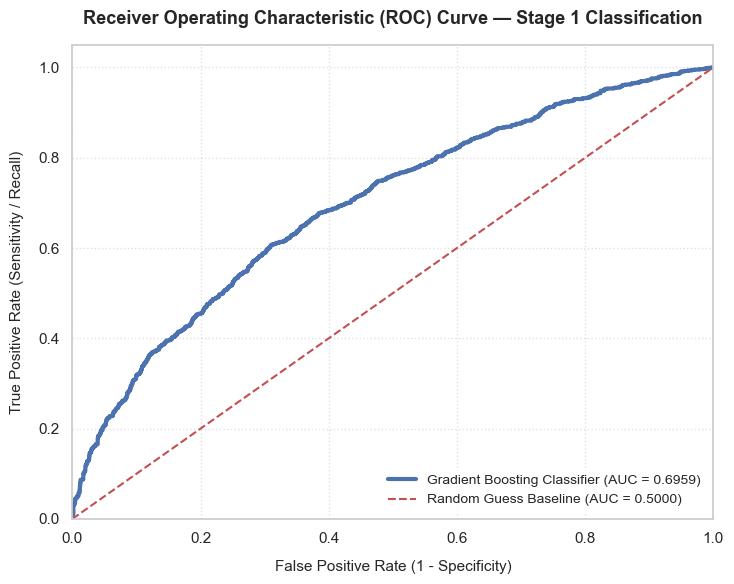

In [81]:
## silenece: 
# 1. Pull the trained Gradient Boosting model from your dictionary
gb_model = class_models['GradientBoost Classifier']

# 2. Get the probability scores for the positive class (the claim event) on the test data
# We use X_test_transformed to match your preprocessed pipeline structure
y_pred_proba = gb_model.predict_proba(X_test_transformed)[:, 1]

# 3. Calculate False Positive Rate, True Positive Rate, and the AUC score
fpr, tpr, thresholds = roc_curve(y_class_test, y_pred_proba)
auc_score = roc_auc_score(y_class_test, y_pred_proba)

# 4. Set up the plotting canvas with a professional look
plt.figure(figsize=(7.5, 6))
sns.set_theme(style="whitegrid")

# Plot the model's ROC curve
plt.plot(
    fpr, 
    tpr, 
    color='#4c72b0', 
    lw=3, 
    label=f'Gradient Boosting Classifier (AUC = {auc_score:.4f})'
)

# Plot the random guess line (50/50 baseline)
plt.plot([0, 1], [0, 1], color='#c44e52', linestyle='--', lw=1.5, label='Random Guess Baseline (AUC = 0.5000)')

# 5. Format axes and labels according to academic standards
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, labelpad=10)
plt.title('Receiver Operating Characteristic (ROC) Curve — Stage 1 Classification', fontsize=13, pad=15, fontweight='bold')

# Position the legend safely in the lower right corner
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)

# 6. Save the high-resolution image directly to your project folder
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [82]:
class_models = {
    'Adaboost Classifier': AdaBoostClassifier(n_estimators= 500, learning_rate= 0.5),
    'GradientBoost Classifier': GradientBoostingClassifier(subsample= 0.8,n_estimators= 100,
 min_samples_split= 5,max_depth= 3,learning_rate= 0.1),
}
    
for name, model in class_models.items():
    print(f"Training {name}...")
    model.fit(X_train_transformed, y_class_train)
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train_transformed)[:, 1]
        y_test_prob = model.predict_proba(X_test_transformed)[:, 1]
    elif hasattr(model, "decision_function"):
        y_train_prob = model.decision_function(X_train_transformed)
        y_test_prob = model.decision_function(X_test_transformed)
    else:
        y_train_prob = None
        y_test_prob = None
    
    acc_train, conf_train, class_rep_train, auc_train = evaluate_model_class(y_class_train, y_train_pred, y_train_prob)
    acc_test, conf_test, class_rep_test, auc_test = evaluate_model_class(y_class_test, y_test_pred, y_test_prob)
    
    print(f"--- {name} Performance ---")
    

    if auc_train is not None:
        print(f"TRAIN | Accuracy: {acc_train:.4f} | ROC-AUC: {auc_train:.4f}")
        print(f"TEST  | Accuracy: {acc_test:.4f}  | ROC-AUC: {auc_test:.4f}")
    else:
        print(f"TRAIN | Accuracy: {acc_train:.4f} | ROC-AUC: N/A")
        print(f"TEST  | Accuracy: {acc_test:.4f}  | ROC-AUC: N/A")
        
    print("\nTest Confusion Matrix:")
    print(conf_test)
    print("\nTest Classification Report:")
    print(class_rep_test)
    print("="*50 + "\n")

Training Adaboost Classifier...
--- Adaboost Classifier Performance ---
TRAIN | Accuracy: 0.7048 | ROC-AUC: 0.7233
TEST  | Accuracy: 0.6997  | ROC-AUC: 0.6937

Test Confusion Matrix:
[[1704  166]
 [ 704  323]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80      1870
           1       0.66      0.31      0.43      1027

    accuracy                           0.70      2897
   macro avg       0.68      0.61      0.61      2897
weighted avg       0.69      0.70      0.67      2897


Training GradientBoost Classifier...
--- GradientBoost Classifier Performance ---
TRAIN | Accuracy: 0.7354 | ROC-AUC: 0.7735
TEST  | Accuracy: 0.6959  | ROC-AUC: 0.6957

Test Confusion Matrix:
[[1670  200]
 [ 681  346]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79      1870
           1       0.63      0.34      0.44      1027

    accuracy        

In [83]:
final_model_class=GradientBoostingClassifier(subsample= 0.8,n_estimators= 100,
 min_samples_split= 5,max_depth= 3,learning_rate= 0.1)

In [84]:
final_model_class.fit(X_train_transformed, y_class_train)

GradientBoostingClassifier(min_samples_split=5, subsample=0.8)

In [85]:
y_pred_final_class = pd.DataFrame(final_model_class.predict(X_test_transformed), index=X_test_transformed.index, columns=['predicted_claim']
)

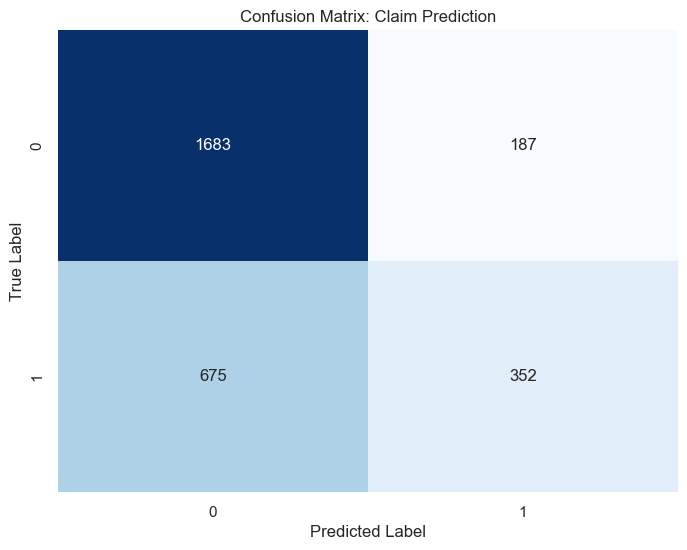

In [86]:
y_pred_class = final_model_class.predict(X_test_transformed)
cm = confusion_matrix(y_class_test, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Claim Prediction')
plt.show()

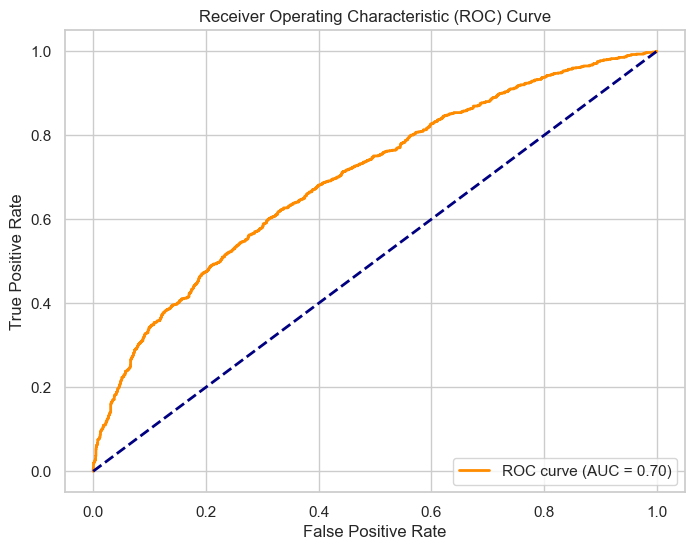

In [87]:
y_probs = final_model_class.predict_proba(X_test_transformed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_class_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [88]:
class_prediction=y_pred_final_class[y_pred_final_class['predicted_claim']==1].index.tolist()

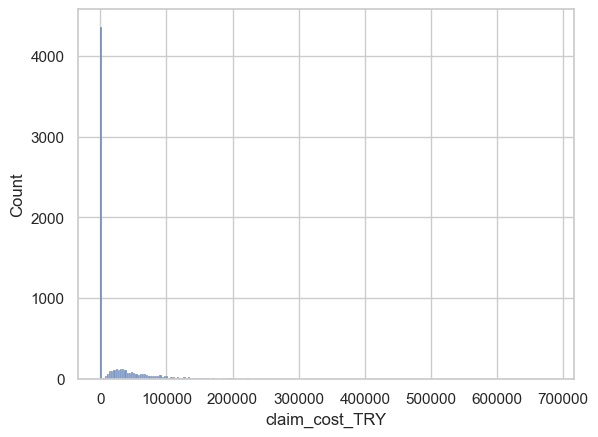

In [89]:
sns.histplot(x=y_reg_train)
plt.show()

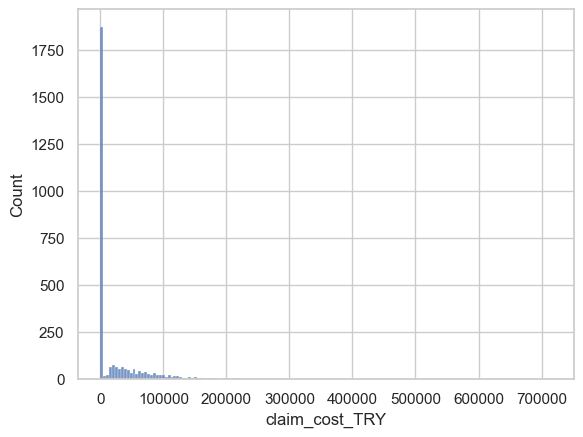

In [90]:
sns.histplot(x=y_reg_test)
plt.show()

In [91]:
yj_transformer = PowerTransformer(method='yeo-johnson')

In [92]:
y_reg_train_transformed = yj_transformer.fit_transform(y_reg_train.values.reshape(-1, 1))
y_reg_test_transformed = yj_transformer.transform(y_reg_test.values.reshape(-1, 1))
print("Transformation complete.")
print(f"Original Mean: {y_reg_train.mean():.2f}")
print(f"Transformed Mean (approx 0): {y_reg_train_transformed.mean():.2f}")

Transformation complete.
Original Mean: 23686.65
Transformed Mean (approx 0): 0.00


In [94]:
##silenecek: 
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model_reg(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2score = r2_score(true, predicted)
    return mae, mse, rmse, r2score

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Adaboost Regressor': AdaBoostRegressor(),
    'GradientBoost Regressor': GradientBoostingRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'LGBM': LGBMRegressor(verbosity=-1)
}

# Dictionary to hold test results for the automated markdown table printout
table_results = []

for name, model in models.items():
    print(f"===========================================")
    print(f"--- Evaluating Model: {name} ---")
    print(f"===========================================")
    
    # Fit and predict
    model.fit(X_train_transformed, y_reg_train_transformed.ravel())
    y_train_pred_transformed = model.predict(X_train_transformed)
    y_test_pred_transformed = model.predict(X_test_transformed)  
    
    # Inverse transform to original TRY scale
    y_train_pred_final = yj_transformer.inverse_transform(y_train_pred_transformed.reshape(-1, 1)).flatten()
    y_test_pred_final = yj_transformer.inverse_transform(y_test_pred_transformed.reshape(-1, 1)).flatten()
    
    # Clean up any potential infinity or NaN issues safely
    y_train_pred_final = np.nan_to_num(y_train_pred_final, nan=0.0, posinf=0.0, neginf=0.0)
    y_test_pred_final = np.nan_to_num(y_test_pred_final, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Calculate metrics
    mae_train, mse_train, rmse_train, r2_train = evaluate_model_reg(y_reg_train, y_train_pred_final)
    mae_test, mse_test, rmse_test, r2_test = evaluate_model_reg(y_reg_test, y_test_pred_final)
    
    # Print out detailed results
    print(f"TRAIN | MAE: {mae_train:,.2f} TRY | MSE: {mse_train:,.2f} | RMSE: {rmse_train:,.2f} TRY | R2: {r2_train:.4f}")
    print(f"TEST  | MAE: {mae_test:,.2f} TRY | MSE: {mse_test:,.2f} | RMSE: {rmse_test:,.2f} TRY | R2: {r2_test:.4f}")
    print("\n")
    
    # Save test results for the markdown table generator
    table_results.append({
        'name': name,
        'mae': mae_test,
        'mse': mse_test,
        'rmse': rmse_test,
        'r2': r2_test
    })

# ==============================================================================
# AUTOMATIC MARKDOWN TABLE GENERATOR
# ==============================================================================
print("##### COPY AND PASTE THIS DIRECTLY INTO YOUR WORD DOCUMENT SECTIONS #####\n")
print("| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |")
print("| :--- | :---: | :---: | :---: | :---: |")
for row in table_results:
    print(f"| {row['name']} | {row['mae']:,.2f} | {row['mse']:,.2f} | {row['rmse']:,.2f} | {row['r2']:.4f} |")

--- Evaluating Model: Linear Regression ---
TRAIN | MAE: 23,680.26 TRY | MSE: 2,949,980,362.89 | RMSE: 54,313.72 TRY | R2: -0.2338
TEST  | MAE: 24,177.45 TRY | MSE: 2,868,938,010.02 | RMSE: 53,562.47 TRY | R2: -0.2550


--- Evaluating Model: Lasso ---
TRAIN | MAE: 23,688.68 TRY | MSE: 2,951,679,708.75 | RMSE: 54,329.36 TRY | R2: -0.2345
TEST  | MAE: 24,185.74 TRY | MSE: 2,870,446,326.84 | RMSE: 53,576.55 TRY | R2: -0.2557


--- Evaluating Model: Ridge ---
TRAIN | MAE: 23,680.26 TRY | MSE: 2,949,981,852.18 | RMSE: 54,313.74 TRY | R2: -0.2338
TEST  | MAE: 24,177.46 TRY | MSE: 2,868,939,266.53 | RMSE: 53,562.48 TRY | R2: -0.2550


--- Evaluating Model: K Neighbors Regressor ---
TRAIN | MAE: 23,190.31 TRY | MSE: 2,876,363,696.19 | RMSE: 53,631.74 TRY | R2: -0.2030
TEST  | MAE: 24,141.29 TRY | MSE: 2,855,839,381.82 | RMSE: 53,440.05 TRY | R2: -0.2493


--- Evaluating Model: Decision Tree Regressor ---
TRAIN | MAE: 0.00 TRY | MSE: 0.00 | RMSE: 0.00 TRY | R2: 1.0000
TEST  | MAE: 37,135.14 TRY

In [97]:
def evaluate_model_reg(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2score = r2_score(true, predicted)
    return mae, mse, rmse, r2score
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Adaboost Regressor': AdaBoostRegressor(),
    'GradientBoost Regressor': GradientBoostingRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'LGBM': LGBMRegressor(verbosity=-1)
}
for name, model in models.items():
    print(f"===========================================")
    print(f"--- Evaluating Model: {name} ---")
    print(f"===========================================")
    model.fit(X_train_transformed, y_reg_train_transformed.ravel())
    y_train_pred_transformed = model.predict(X_train_transformed)
    y_test_pred_transformed = model.predict(X_test_transformed)  
    y_train_pred_final = yj_transformer.inverse_transform(y_train_pred_transformed.reshape(-1, 1))
    y_test_pred_final = yj_transformer.inverse_transform(y_test_pred_transformed.reshape(-1, 1))
    y_train_pred_final = y_train_pred_final.flatten()
    y_test_pred_final = y_test_pred_final.flatten()
    y_train_pred_final = np.nan_to_num(y_train_pred_final, nan=0.0, posinf=0.0, neginf=0.0)
    y_test_pred_final = np.nan_to_num(y_test_pred_final, nan=0.0, posinf=0.0, neginf=0.0)
    mae_train, mse_train, rmse_train, r2_train = evaluate_model_reg(y_reg_train, y_train_pred_final)
    mae_test, mse_test, rmse_test, r2_test = evaluate_model_reg(y_reg_test, y_test_pred_final)
    
    print(f"TRAIN | MAE: {mae_train:.2f} TRY | R2: {r2_train:.4f}")
    print(f"TEST  | MAE: {mae_test:.2f} TRY | R2: {r2_test:.4f}")
    print("\n")

--- Evaluating Model: Linear Regression ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: Lasso ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: Ridge ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: K Neighbors Regressor ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: Decision Tree Regressor ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: Random Forest ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: Adaboost Regressor ---
| Model | MAE (TRY) | MSE | RMSE (TRY) | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
--- Evaluating Model: GradientBoost Regressor ---
| Model | MAE (TRY) | MSE | R

In [ ]:
X_train_df = pd.DataFrame(X_train_transformed)
y_reg_train_reset = y_reg_train.reset_index(drop=True)
combined_df = pd.concat([X_train_df, y_reg_train_reset], axis=1)

In [ ]:
combined_df=combined_df.drop('coverage_type',axis=1)

In [ ]:
combined_df.info()

In [ ]:
combined_df.corr()

In [99]:
print("--- Spearman Rank Correlation with claim_cost_TRY ---")
# Filter data for actual claimants just like your regression stage does
claimant_data = df[df['had_claim'] == 1]

# Check numeric columns against your target cost
numeric_cols = claimant_data.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if col != 'claim_cost_TRY':
        coef, p_value = spearmanr(claimant_data[col], claimant_data['claim_cost_TRY'], nan_policy='omit')
        print(f"{col:<25} | Spearman r_s: {coef:.4f} | p-value: {p_value:.4e}")

--- Spearman Rank Correlation with claim_cost_TRY ---
transmission_type         | Spearman r_s: 0.0279 | p-value: 9.6222e-02
engine_size_cc            | Spearman r_s: -0.0317 | p-value: 5.8235e-02
num_seats                 | Spearman r_s: 0.0032 | p-value: 8.4753e-01
vehicle_age_years         | Spearman r_s: 0.0680 | p-value: 4.7936e-05
vehicle_value_TRY         | Spearman r_s: -0.0065 | p-value: 6.9954e-01
prev_owners               | Spearman r_s: 0.0013 | p-value: 9.3681e-01
driver_age                | Spearman r_s: 0.0147 | p-value: 3.8041e-01
driving_exp_years         | Spearman r_s: 0.0149 | p-value: 3.7265e-01
gender                    | Spearman r_s: 0.0039 | p-value: 8.1619e-01
annual_mileage_km         | Spearman r_s: 0.0006 | p-value: 9.7073e-01
prev_claims_3yr           | Spearman r_s: 0.0024 | p-value: 8.8597e-01
has_garage                | Spearman r_s: 0.0300 | p-value: 7.3207e-02
anti_theft_device         | Spearman r_s: 0.0147 | p-value: 3.7873e-01
policy_tenure_years  

C:\Users\dolap\AppData\Local\Temp\ipykernel_26768\2974994791.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  coef, p_value = spearmanr(claimant_data[col], claimant_data['claim_cost_TRY'], nan_policy='omit')
